# Setup Directories & Relevant Parameters

In [351]:
telescope = 'VLA'
source = '04264+2433'
target = '04264+2433B'
cont_dir = f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/{source}/continuum/{telescope}'

In [352]:
from astropy import units as u

if telescope == 'ALMA':
    opacity = 1.84 * u.cm**2 / u.g 
    nu = 345 * u.GHz 
    robust = 0.5
if telescope == 'VLA':
    opacity = 0.13 * u.cm**2 / u.g
    nu = 33 * u.GHz
    robust = 2.0
if telescope == 'SMA':
    opacity = 2.0 * u.cm**2 / u.g # needs to double check 
    nu = 230 * u.GHz 
    robust = 0.5
print(f"Opacity: {opacity:.2e}")
print(f"Frequency (GHz): {nu:.2e}")

Opacity: 1.30e-01 cm2 / g
Frequency (GHz): 3.30e+01 GHz


# imfit/imstat

In [353]:
from casatools import image
ia = image()
clean_img = f'{cont_dir}/clean/clean_continuum_{source}_{robust}.image.pbcor'
try:
    ia.open(clean_img)
    ia.close()
except Exception:
    clean_img = f'{cont_dir}/clean/clean_continuum_{source}_{robust}_image_pbcor.fits'
region = f'{cont_dir}/clean/{target}_{telescope}_region' # .. first try A, B then report non detection if does not exist
print(region)
imfit_file = f'{cont_dir}/{target}-imfit-summary.txt'
imstat_file = f'{cont_dir}/{target}-imstat-summary.txt'
#estimates = f'{cont_dir}/{target}_{telescope}_estimates.txt'
imfit_result = imfit(imagename = clean_img, region = region, summary = imfit_file)
stats = imstat(imagename= clean_img, region = region, logfile = imstat_file)

/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04264+2433/continuum/VLA/clean/04264+2433B_VLA_region


2025-04-04 16:25:18	SEVERE	image::open (file src/tools/image/image_cmpt.cc, line 4208)	Exception Reported: Exception: Unable to open image /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/04264+2433/continuum/VLA/clean/clean_continuum_04264+2433_2.0.image.pbcor.
2025-04-04 16:25:18	SEVERE	image::open (file src/tools/image/image_cmpt.cc, line 4208)+	... thrown by static casa::ITUPLE casa::ImageFactory::fromFile(const casacore::String&, casacore::Bool) at File: /source/casa6/casatools/src/code/imageanalysis/ImageAnalysis/ImageFactory2.cc, line: 289


# Mass Calculation

$$
M = \frac{d^2 \cdot F_\nu}{\kappa_\nu \cdot B_\nu}
$$

To propagate the uncertainty in mass:

$$
\sigma_M = \sqrt{\left( \frac{\partial M}{\partial d} \cdot \sigma_d \right)^2 + \left( \frac{\partial M}{\partial F_\nu} \cdot \sigma_{F_\nu} \right)^2}
$$

Partial derivative with respect to distance:

$$
\frac{\partial M}{\partial d} = \frac{2d \cdot F_\nu}{\kappa_\nu \cdot B_\nu}
$$

Partial derivative with respect to flux:

$$
\frac{\partial M}{\partial F_\nu} = \frac{d^2}{\kappa_\nu \cdot B_\nu}
$$

Total uncertainty in mass:

$$
\sigma_M = \sqrt{\left( \frac{2d \cdot F_\nu}{\kappa_\nu \cdot B_\nu} \cdot \sigma_d \right)^2 + \left( \frac{d^2}{\kappa_\nu \cdot B_\nu} \cdot \sigma_{F_\nu} \right)^2}
$$

In [354]:
# Constants
from astropy import constants as const

T_dust = 43 * u.K
d_pc = 140 * u.pc
d = d_pc.to(u.cm)

h = const.h.cgs  # Planck constant in erg·s
c = const.c.cgs  # Speed of light in cm/s
k_B = const.k_B.cgs  # Boltzmann constant in erg/K

print(f"h: {h}, c: {c}, k_B: {k_B}, T_dust: {T_dust}, d: {d}")

h: 6.62607015e-27 erg s, c: 29979245800.0 cm / s, k_B: 1.380649e-16 erg / K, T_dust: 43.0 K, d: 4.3199486140879136e+20 cm


In [355]:
# Blackbody
from astropy.modeling.models import BlackBody

bb = BlackBody(temperature=T_dust)
nu_Hz = nu.to(u.Hz)
B_nu = bb(nu_Hz) * u.sr
print(f"B_nu: {B_nu}")

B_nu: 1.4123613472323554e-14 erg / (Hz s cm2)


In [356]:
# Mass
imfit_parts = [l for l in open(f'{cont_dir}/{target}-imfit-summary.txt') if not l.startswith("#")][0].split()
F = float(imfit_parts[1]) * 1e-23 * u.erg / (u.s * u.cm**2 * u.Hz)
F_err = float(imfit_parts[2]) * 1e-23 * u.erg / (u.s * u.cm**2 * u.Hz)
M = (d**2 * F) / (opacity * B_nu)

# Uncertainty
dM_dd = 2 * d * F / (opacity * B_nu)
dM_dF = d**2 / (opacity * B_nu)
    
sigma_d = 0.1 * d # distance uncertainty

sigma_F = np.sqrt(F_err**2 + (0.1 * F)**2) # flux uncertainty: F_err = uncertainty from gaussian fit; 0.1 * F = 10% uncertainty on the measured flux
    
sigma_M = np.sqrt((dM_dd * sigma_d)**2 + (dM_dF * sigma_F)**2)

# Convert to Earth masses
MEarth = M.to(u.M_earth)
sigma_MEarth = sigma_M .to(u.M_earth)

print(f"Mass (Earth Mass): {MEarth.value:.3f} ± {sigma_MEarth.value:.3f}")

Mass (Earth Mass): 19.460 ± 5.601


# Radius Calculation

### Beam-Limited Deconvolution and Error Propagation

When the source is smaller than the beam, the deconvolved major and minor axes are approximated as:

$$
\text{deconv\_major\_axis} = \frac{\text{beam\_major\_axis}}{\sqrt{\text{SNR}}}
$$

$$
\text{deconv\_minor\_axis} = \frac{\text{beam\_minor\_axis}}{\sqrt{\text{SNR}}}
$$

#### Error Propagation for Deconvolved Axes

The propagated error for the deconvolved major axis is:

$$
\sigma_{\text{deconv\_major\_axis}} = \frac{0.5 \cdot \sigma_{\text{SNR}} \cdot \text{beam\_major\_axis}}{\text{SNR}^{1.5}}
$$

And for the minor axis:

$$
\sigma_{\text{deconv\_minor\_axis}} = \frac{0.5 \cdot \sigma_{\text{SNR}} \cdot \text{beam\_minor\_axis}}{\text{SNR}^{1.5}}
$$

#### Final Error Propagation Formula

For completeness, the error propagation formula is:

$$
\sigma_{\text{deconv\_major\_axis}} = \sqrt{\left( \frac{0.5 \cdot \sigma_{\text{SNR}} \cdot \text{beam\_major\_axis}}{\text{SNR}^{1.5}} \right)^2}
$$

$$
\sigma_{\text{deconv\_minor\_axis}} = \sqrt{\left( \frac{0.5 \cdot \sigma_{\text{SNR}} \cdot \text{beam\_minor\_axis}}{\text{SNR}^{1.5}} \right)^2}
$$

In [357]:
# Check if the source is resolved or not
imfit_parts = [l for l in open(f'{cont_dir}/{target}-imfit-summary.txt') if not l.startswith("#")][0].split()
decon_maj = float(imfit_parts[15]) * u.arcsec
decon_min = float(imfit_parts[16]) * u.arcsec
decon_maj_err = float(imfit_parts[18]) * u.arcsec
decon_min_err = float(imfit_parts[19]) * u.arcsec

resolved_maj = decon_maj > 2 * decon_maj_err
resolved_min = decon_min > 2 * decon_min_err
resolved = resolved_maj and resolved_min

if resolved:
    print("Source is resolved.")
    R = (decon_maj / 2) * d_pc * u.au 
    sigma_R = (decon_maj_err / 2) * d_pc * u.au
    print(f"Resolved radius: {R.value:.2f} ± {sigma_R.value:.2f} AU")
else: 
    print(f"Source is unresolved or marginally resolved. major axis: {resolved_maj}; minor axis: {resolved_min}")
    con_maj = float(imfit_parts[9]) * u.arcsec
    con_maj_err = float(imfit_parts[12]) * u.arcsec
    
    peak = float(imfit_parts[3])
    residual_stats = imstat(imagename=f'{cont_dir}/clean/clean_continuum_{source}_{robust}_residual.fits')
    rms = residual_stats['rms'][0]
    snr = peak / rms
    
    theta_limit = con_maj / snr**0.5
    R_upper = (theta_limit / 2) * d_pc * u.au
    theta_limit_err = con_maj_err / snr**0.5
    sigma_R_upper = (theta_limit_err / 2) * d_pc * u.au
    print(f"Unresolved radius: {R_upper.value:.2f} ± {sigma_R_upper.value:.2f} AU")

Source is unresolved or marginally resolved. major axis: True; minor axis: False
Unresolved radius: 10.23 ± 1.42 AU


# Inclination

### Inclination Angle Calculation

The inclination angle $i$ is calculated as:

$$
i = \cos^{-1} \left( \frac{x}{y} \right)
$$

where:  
- $x$ = deconvolved minor axis  
- $y$ = deconvolved major axis  

---

### Error Propagation for Inclination Angle

We propagate the errors in both $x$ and $y$ using:

$$
\sigma_i = \sqrt{
\left( \frac{\partial i}{\partial x} \cdot \sigma_x \right)^2 +
\left( \frac{\partial i}{\partial y} \cdot \sigma_y \right)^2
}
$$

where:  
- $\sigma_x$ = uncertainty in the deconvolved minor axis  
- $\sigma_y$ = uncertainty in the deconvolved major axis  

---

#### Partial Derivatives

$$
\frac{\partial i}{\partial x} = -\frac{1}{\sqrt{1 - \left( \frac{x}{y} \right)^2}} \cdot \frac{1}{y}
$$

$$
\frac{\partial i}{\partial y} = \frac{1}{\sqrt{1 - \left( \frac{x}{y} \right)^2}} \cdot \frac{x}{y^2}
$$

---

#### Final Error Propagation Formula

$$
\sigma_i = \sqrt{
\left( \frac{1}{\sqrt{1 - \left( \frac{x}{y} \right)^2}} \cdot \frac{\sigma_x}{y} \right)^2 +
\left( \frac{1}{\sqrt{1 - \left( \frac{x}{y} \right)^2}} \cdot \frac{x \cdot \sigma_y}{y^2} \right)^2
}
$$

In [358]:
imfit_parts = [l for l in open(f'{cont_dir}/{target}-imfit-summary.txt') if not l.startswith("#")][0].split()
deconv_maj = float(imfit_parts[15]) 
deconv_min = float(imfit_parts[16]) 
deconv_maj_err = float(imfit_parts[18]) 
deconv_min_err = float(imfit_parts[19])

i = np.degrees(np.arccos(deconv_min / deconv_maj))

xy = deconv_min / deconv_maj

denominator = np.sqrt(1 - xy**2)

didx = -1 / (denominator * deconv_maj)
didy = xy / (denominator * deconv_maj)

sigma_i = np.degrees(np.sqrt((didx * deconv_min_err)**2 + (didy * deconv_maj_err)**2))

print(f"Inclination: {i:.2f} ± {sigma_i:.2f} degrees")

Inclination: 69.22 ± 13.57 degrees


# Position Angle

In [359]:
imfit_parts = [l for l in open(f'{cont_dir}/{target}-imfit-summary.txt') if not l.startswith("#")][0].split()
pa = float(imfit_parts[17])
sigma_pa = float(imfit_parts[20])
print(f"PA: {pa:.2f} ± {sigma_pa:.2f} degrees")

PA: 135.54 ± 24.59 degrees


# Save to a .dat file

In [360]:
name = target
imfit_parts = [l for l in open(f'{cont_dir}/{target}-imfit-summary.txt') if not l.startswith("#")][0].split()
ra = float(imfit_parts[5])  # LongICRS (RA in degrees)
dec = float(imfit_parts[6]) # LatICRS (Dec in degrees)
f = float(imfit_parts[1]) # Jy
sigma_f = float(imfit_parts[2])

if resolved:
    resolved_flag = True
    radius = R.value
    sigma_radius = sigma_R.value
else:
    resolved_flag = False
    radius = R_upper.value
    sigma_radius = sigma_R_upper.value

output_file = f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/{telescope}_data/{telescope.lower()}_continuum_measurements.dat'
if not os.path.exists(output_file):
    with open(output_file, 'w') as f_out:
        f_out.write("source,ra(deg),dec(deg),f(mJy),e_f(mJy),mass(earth_mass),e_mass(earth_mass),resolved,radius(au),e_radius(au),incl(deg),e_incl(deg),pa(deg),e_pa(deg)\n")
with open(output_file, 'a') as f_out:
    f_out.write(f"{name},{ra:.6f},{dec:.6f},{f*1e3:.5f},{sigma_f*1e3:.5f},{MEarth.value:.3f},{sigma_MEarth.value:.3f},{resolved_flag},{radius:.2f},{sigma_radius:.2f},{i:.2f},{sigma_i:.2f},{pa:.2f},{sigma_pa:.2f}\n")

# Make CDFs

In [6]:
# Collect values from .dat files 
taurus_ALMA = np.genfromtxt(f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/alma_continuum_measurements.dat', delimiter=",", names=True, dtype=None, encoding="utf-8")#taurus 345 GHz
taurus_VLA = np.genfromtxt(f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/VLA_data/vla_continuum_measurements.dat', delimiter=",", names=True, dtype=None, encoding="utf-8")#taurus 33 GHz
orion = np.genfromtxt(f'/lustre/cv/users/psheehan/ForNoshin/araa_protostars_figures/data/table-alma-vla-patrick.txt', names=True, dtype=None, encoding='utf-8')
orionI = orion[orion['class'] == 'I'] # only comparing with Class I because Taurus sample has only 1/2 sources class 0 but Orion has many. 
orion0 = orion[orion['class'] == '0']
oph = np.genfromtxt(f'/lustre/cv/users/psheehan/ForNoshin/araa_protostars_figures/data/encalada.txt', names=True, dtype=None, encoding='utf-8')
ophI = oph[oph['Class'] == 'I']
oph0 = oph[oph['Class'] == '0']

In [29]:
# Plotting cdfs
from matplotlib.patches import Polygon

def plot_cdf(property_name, sample_label, property_vals, color, hatch_fill=False):
    """
    Adds a Kaplan-Meier CDF to the current plot, with optional hatched fill.
    """
    kmf = KaplanMeierFitter(alpha=0.32)
    kmf.fit(property_vals, event_observed=np.ones(len(property_vals)))

    survival = kmf.survival_function_
    ci = kmf.confidence_interval_

    xmin = np.min(property_vals)
    valid = survival.index >= xmin

    x = survival.index[valid]
    y = survival.loc[valid, "KM_estimate"].values.flatten()
    lower = ci.loc[valid, "KM_estimate_lower_0.68"].values.flatten()
    upper = ci.loc[valid, "KM_estimate_upper_0.68"].values.flatten()

    if not hatch_fill:
        plt.fill_between(x, lower, upper, color=color, alpha=0.4)
    else:
        plt.fill_between(x, lower, upper, color=color, alpha=0.4)
        verts = list(zip(x, lower)) + list(zip(x[::-1], upper[::-1]))
        poly = Polygon(verts, closed=True, facecolor='none',
                       edgecolor='black', hatch='///', linewidth=0.0)
        plt.gca().add_patch(poly)

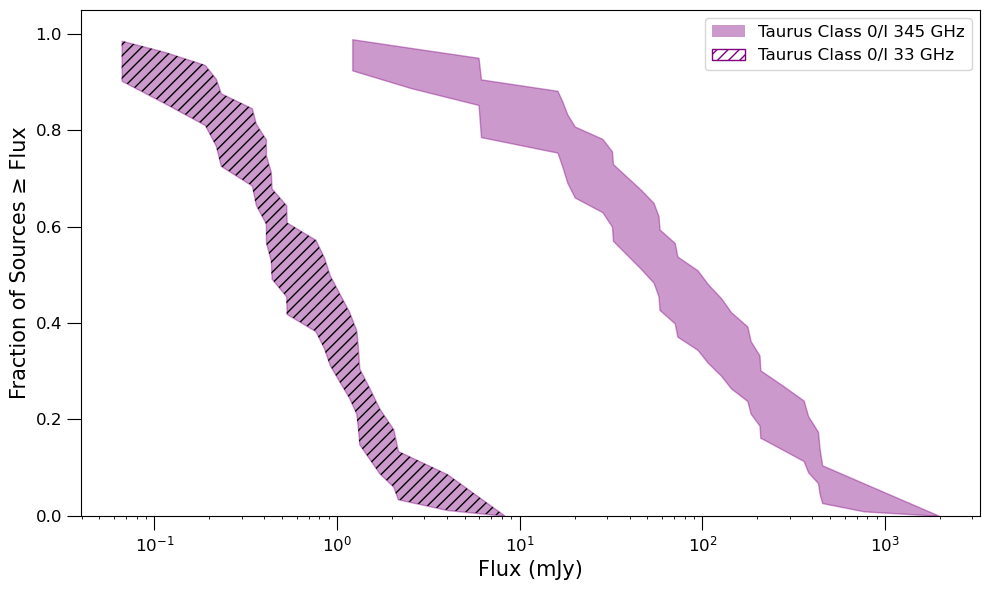

In [38]:
# Flux
plt.figure(figsize=(10, 6))

taurus_ALMA_Flux = np.array(taurus_ALMA['fmJy'][taurus_ALMA['fmJy'] > 0])
taurus_VLA_Flux = np.array(taurus_VLA['fmJy'][taurus_VLA['fmJy'] > 0])
orion0_ALMA_Flux = np.array(orion0['intflux_alma_mJy'][orion0['intflux_alma_mJy'] > 0])
orion0_VLA_Flux = np.array(orion0['intflux_vla_mJy'][orion0['intflux_vla_mJy'] > 0])
orionI_ALMA_Flux = np.array(orionI['intflux_alma_mJy'][orionI['intflux_alma_mJy'] > 0])
orionI_VLA_Flux = np.array(orionI['intflux_vla_mJy'][orionI['intflux_vla_mJy'] > 0])
orion_dist_factor = (400 / 140)**2
scaled_orion0_ALMA_Flux = orion0_ALMA_Flux * orion_dist_factor
scaled_orion0_VLA_Flux = orion0_VLA_Flux * orion_dist_factor
scaled_orionI_ALMA_Flux = orionI_ALMA_Flux * orion_dist_factor
scaled_orionI_VLA_Flux = orionI_VLA_Flux * orion_dist_factor
oph0_345 = np.array(oph0['F_nu'][oph0['F_nu'] > 0])
ophI_345 = np.array(ophI['F_nu'][ophI['F_nu'] > 0])

samples = [
    {
        'label': 'Taurus Class 0/I 345 GHz',
        'values': taurus_ALMA_Flux,
        'color': 'purple'
    },
    {
        'label': 'Taurus Class 0/I 33 GHz',
        'values': taurus_VLA_Flux,
        'color': 'purple',
        'hatch_fill': True
    },
    {
         'label': 'Orion Class I 345 GHz',
         'values': scaled_orionI_ALMA_Flux,
         'color': 'forestgreen'
    },
    {
         'label': 'Orion Class I 33 GHz',
         'values': scaled_orionI_VLA_Flux,
         'color': 'forestgreen',
         'hatch_fill': True
    },
    {
         'label': 'Ophiuchus Class I 345 GHz',
         'values': ophI_345,
         'color': 'red'
    }
   ]

for sample in samples:
    plot_cdf(
        "Flux (mJy)",
        sample['label'],
        sample['values'],
        sample['color'],
        hatch_fill=sample.get('hatch_fill', False)
    )

plt.xlabel("Flux (mJy)", fontsize=15)
plt.ylabel("Fraction of Sources ≥ Flux", fontsize=15)
plt.xscale("log")
plt.ylim(0, 1.05)
plt.tick_params(axis='both', which='major', labelsize=12, length=10)
import matplotlib.patches as mpatches

legend_handles = []

for sample in samples:
    if sample.get('hatch_fill', False):
        patch = mpatches.Patch(facecolor='white', hatch='///',
                               edgecolor=sample['color'], label=sample['label'])
    else:
        patch = mpatches.Patch(facecolor=sample['color'], edgecolor='none',
                               alpha=0.4, label=sample['label'])
    legend_handles.append(patch)

plt.legend(handles=legend_handles, fontsize=12)
plt.tight_layout()
plt.savefig('flux_cdfs.png')
plt.show()

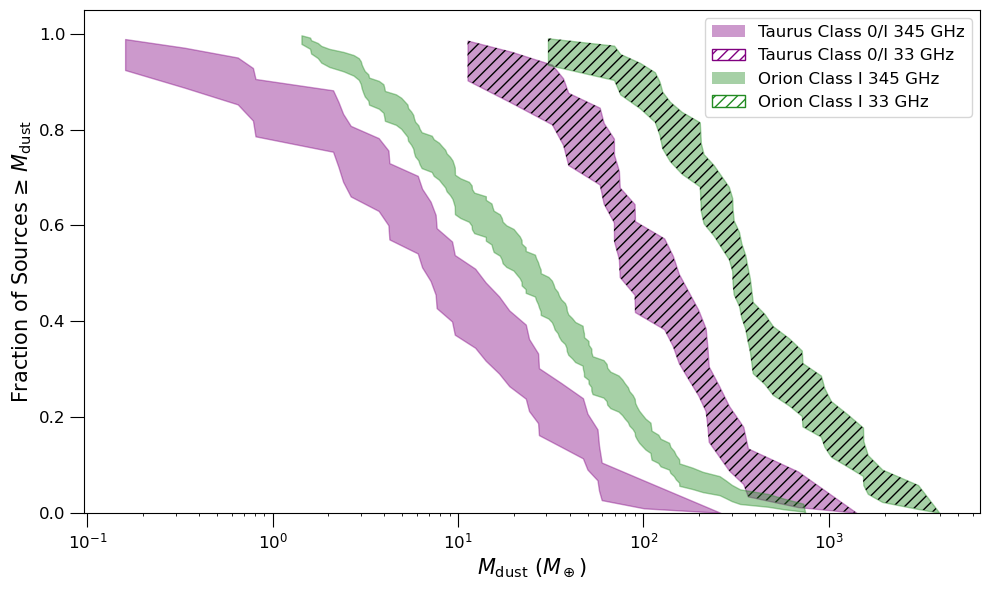

In [46]:
# Mass
taurus_ALMA_Mass = np.array(taurus_ALMA['massearth_mass'][taurus_ALMA['massearth_mass'] > 0])
taurus_VLA_Mass = np.array(taurus_VLA['massearth_mass'][taurus_VLA['massearth_mass'] > 0])

from astropy.constants import M_earth, c, h, k_B
from astropy.modeling.models import BlackBody
from astropy import units as u

def cal_mass(flux_cgs, frequency_GHz, opacity, dist, T_dust=43 * u.K):
    """
    Calculates the disk mass in Earth masses.
    """
    dist_cm = dist.to(u.cm)
    nu_Hz = frequency_GHz.to(u.Hz)
    blackbody = BlackBody(temperature=T_dust)
    B_nu = blackbody(nu_Hz)
    M = (dist_cm ** 2 * flux_cgs) / (opacity * B_nu)
    mass_earth = (M / u.sr).to(u.M_earth)

    return mass_earth

orionI_ALMA_Flux_Jy = (orionI_ALMA_Flux * u.mJy).to(u.Jy)
orionI_ALMA_Flux_cgs = orionI_ALMA_Flux_Jy.to(u.erg / (u.cm**2 * u.s * u.Hz))
orionI_ALMA_Mass = cal_mass(flux_cgs = orionI_ALMA_Flux_cgs, frequency_GHz = 345*u.GHz, opacity = 1.84 * u.cm**2 / u.g, dist = 400 * u.pc, T_dust=43 * u.K)
orionI_VLA_Flux_Jy = (orionI_VLA_Flux * u.mJy).to(u.Jy)
orionI_VLA_Flux_cgs = orionI_VLA_Flux_Jy.to(u.erg / (u.cm**2 * u.s * u.Hz))
orionI_VLA_Mass = cal_mass(flux_cgs = orionI_VLA_Flux_cgs, frequency_GHz = 33*u.GHz, opacity = 0.13 * u.cm**2 / u.g, dist = 400 * u.pc, T_dust=43 * u.K)

plt.figure(figsize=(10, 6))

samples = [
    {
        'label': 'Taurus Class 0/I 345 GHz',
        'values': taurus_ALMA_Mass,
        'color': 'purple'
    },
    {
        'label': 'Taurus Class 0/I 33 GHz',
        'values': taurus_VLA_Mass,
        'color': 'purple',
        'hatch_fill': True
    },
    {
         'label': 'Orion Class I 345 GHz',
         'values': orionI_ALMA_Mass,
         'color': 'forestgreen'
    },
    {
         'label': 'Orion Class I 33 GHz',
         'values': orionI_VLA_Mass,
         'color': 'forestgreen',
         'hatch_fill': True
    },
   ]

for sample in samples:
    plot_cdf(
        r"$M_{\mathrm{dust}}$ ($M_\oplus$)",
        sample['label'],
        sample['values'],
        sample['color'],
        hatch_fill=sample.get('hatch_fill', False)
    )

plt.xlabel(r"$M_{\mathrm{dust}}$ ($M_\oplus$)", fontsize=15)
plt.ylabel(r"Fraction of Sources ≥ $M_{\mathrm{dust}}$", fontsize=15)
plt.xscale("log")
plt.ylim(0, 1.05)
plt.tick_params(axis='both', which='major', labelsize=12, length=10)
import matplotlib.patches as mpatches

legend_handles = []

for sample in samples:
    if sample.get('hatch_fill', False):
        patch = mpatches.Patch(facecolor='white', hatch='///',
                               edgecolor=sample['color'], label=sample['label'])
    else:
        patch = mpatches.Patch(facecolor=sample['color'], edgecolor='none',
                               alpha=0.4, label=sample['label'])
    legend_handles.append(patch)

plt.legend(handles=legend_handles, fontsize=12)
plt.tight_layout()
plt.savefig('mass_cdfs.png')
plt.show()

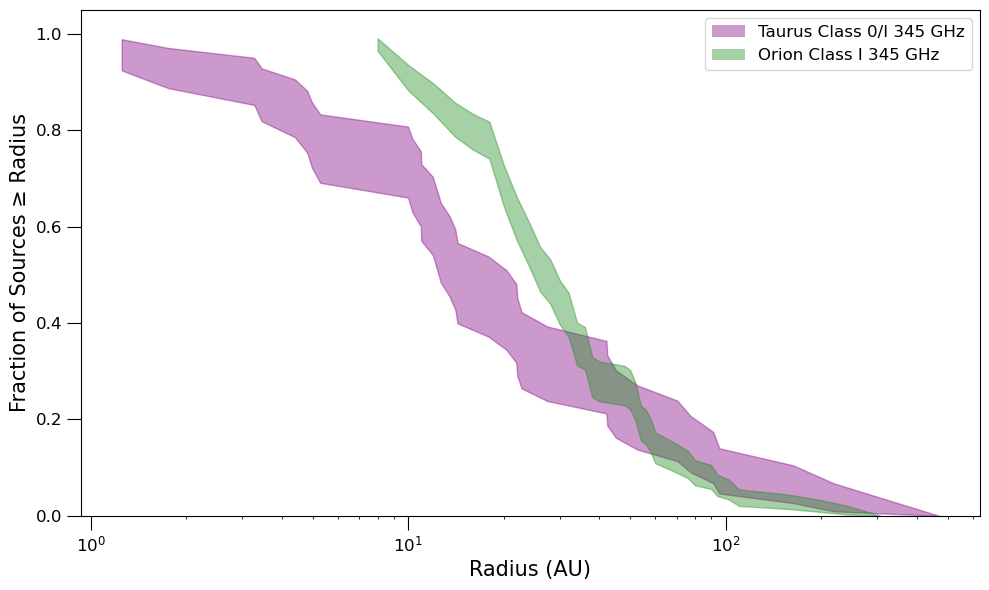

In [45]:
# Radius
plt.figure(figsize=(10, 6))

taurus_ALMA_radius = np.array(taurus_ALMA['radiusau'][taurus_ALMA['radiusau'] > 2*taurus_ALMA['e_radiusau']])
taurus_VLA_radius = np.array(taurus_VLA['radiusau'][taurus_VLA['radiusau'] > 2*taurus_VLA['e_radiusau']])

# Orion Class 0 ALMA radius
mask0_ALMA = (orion0['decon_bmaj_alma'] > 0) & (orion0['decon_bmaj_alma'] > 2 * orion0['e_decon_bmaj_alma'])
orion0_ALMA_radius = 0.5 * orion0['decon_bmaj_alma'][mask0_ALMA] * 400  # arcsec to AU

# Orion Class 0 VLA radius
mask0_VLA = (orion0['decon_bmaj_vla'] > 0) & (orion0['decon_bmaj_vla'] > 2 * orion0['e_decon_bmaj_vla'])
orion0_VLA_radius = 0.5 * orion0['decon_bmaj_vla'][mask0_VLA] * 400

# Orion Class I ALMA radius
maskI_ALMA = (orionI['decon_bmaj_alma'] > 0) & (orionI['decon_bmaj_alma'] > 2 * orionI['e_decon_bmaj_alma'])
orionI_ALMA_radius = 0.5 * orionI['decon_bmaj_alma'][maskI_ALMA] * 400

# Orion Class I VLA radius
maskI_VLA = (orionI['decon_bmaj_vla'] > 0) & (orionI['decon_bmaj_vla'] > 2 * orionI['e_decon_bmaj_vla'])
orionI_VLA_radius = 0.5 * orionI['decon_bmaj_vla'][maskI_VLA] * 400

samples = [
    {
        'label': 'Taurus Class 0/I 345 GHz',
        'values': taurus_ALMA_radius,
        'color': 'purple'
    },
    #{
        #'label': 'Taurus Class I 33 GHz',
        #'values': taurus_VLA_radius,
        #'color': 'blue'
    #},
    {
        'label': 'Orion Class I 345 GHz',
        'values': orionI_ALMA_radius,
        'color': 'forestgreen'
    },
]

for sample in samples:
    plot_cdf("Radius (AU)", sample['label'], sample['values'], sample['color'])

plt.xlabel("Radius (AU)", fontsize=15)
plt.ylabel("Fraction of Sources ≥ Radius", fontsize=15)
plt.xscale("log")
plt.ylim(0, 1.05)
plt.tick_params(axis='both', which='major', labelsize=12, length=10)
import matplotlib.patches as mpatches

legend_handles = []
for sample in samples:
    patch = mpatches.Patch(facecolor=sample['color'], alpha=0.4, label=sample['label'])
    legend_handles.append(patch)

plt.legend(handles=legend_handles, fontsize=12)
plt.tight_layout()
plt.savefig('radii_cdfs.png')
plt.show()

# Taurus Sample Image

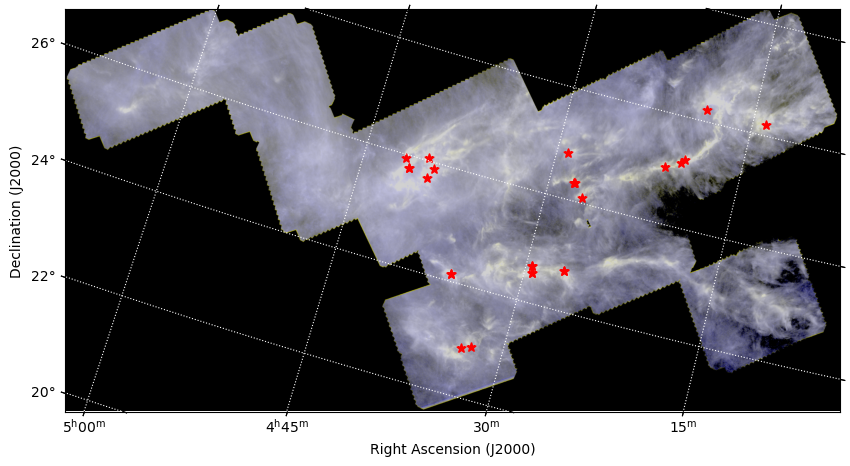

In [26]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import make_lupton_rgb
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import skycoord_to_pixel
import astropy.units as u

hdul = fits.open("/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/TMC_Herschel.fits")

red = hdul['red'].data.astype(float)
green = hdul['green'].data.astype(float)
blue = hdul['blue'].data.astype(float)

rgb = make_lupton_rgb(red, green, blue, stretch=10, Q=8)

wcs = WCS(hdul['red'].header)

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(projection=wcs)
ax.imshow(rgb, origin='lower')

mask = taurus_ALMA['radeg'] > 0
ra = taurus_ALMA['radeg'][mask]
dec = taurus_ALMA['decdeg'][mask]
coords = SkyCoord(ra, dec, unit='deg')
xpix, ypix = skycoord_to_pixel(coords, wcs)
inside_mask = (xpix >= 0) & (xpix < red.shape[1]) & (ypix >= 0) & (ypix < red.shape[0])
ra_in = ra[inside_mask]
dec_in = dec[inside_mask]

ax.scatter(ra_in, dec_in, transform=ax.get_transform('world'),
           s=40, color='red', marker='*', linewidth=1.2, label='Class 0/I Sources')

ax.set_xlabel('Right Ascension (J2000)')
ax.set_ylabel('Declination (J2000)')
ax.coords.grid(True, color='white', ls='dotted')

plt.savefig('/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/TMC_sample.png')
plt.show()

/tmp/ipykernel_2655953/3743094124.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ra.to_string(unit=u.hour, sep=':', precision=0) for ra in ra_coords.ra])
/tmp/ipykernel_2655953/3743094124.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([dec.to_string(unit=u.deg, sep=':', precision=0, alwayssign=True) for dec in dec_coords.dec])


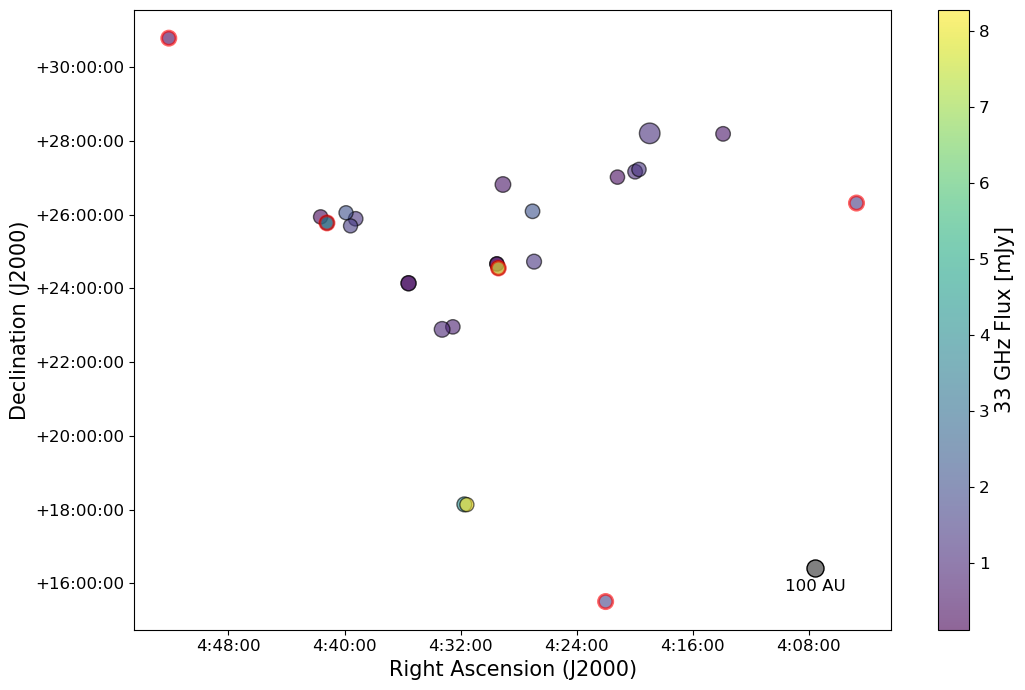

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

df = pd.read_csv('/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/VLA_data/vla_continuum_measurements.dat')

df = df[df['f(mJy)'] > 0]
df = df.sort_values(by='f(mJy)', ascending=True)

resolved_flags = df['resolved'].astype(str).str.lower()
is_resolved = resolved_flags == 'true'
is_minor_unresolved = resolved_flags.str.contains('minor', case=False)
treated_as_resolved = is_resolved | is_minor_unresolved
is_unresolved = ~treated_as_resolved

coords = SkyCoord(ra=df['ra(deg)'].values * u.deg,
                  dec=df['dec(deg)'].values * u.deg)

radii = df['radius(au)']
sizes = 100 + 0.5 * radii  

fig, ax = plt.subplots(figsize=(11, 7))

sc2 = ax.scatter(coords.ra.deg[treated_as_resolved], coords.dec.deg[treated_as_resolved],
                 c=df['f(mJy)'][treated_as_resolved], cmap='viridis', alpha = 0.6,
                 s=sizes[treated_as_resolved], edgecolors='black', marker='o')

sc1 = ax.scatter(coords.ra.deg[is_unresolved], coords.dec.deg[is_unresolved],
                 c=df['f(mJy)'][is_unresolved], cmap='viridis', alpha = 0.6,
                 s=sizes[is_unresolved], edgecolors='red', linewidths=2.0, marker='o')

ra_ticks = ax.get_xticks()
dec_ticks = ax.get_yticks()
ra_coords = SkyCoord(ra=ra_ticks * u.deg, dec=0 * u.deg)
dec_coords = SkyCoord(ra=0 * u.deg, dec=dec_ticks * u.deg)

ax.set_xticklabels([ra.to_string(unit=u.hour, sep=':', precision=0) for ra in ra_coords.ra])
ax.set_yticklabels([dec.to_string(unit=u.deg, sep=':', precision=0, alwayssign=True) for dec in dec_coords.dec])
ax.tick_params(axis='both', which='major', labelsize=12)
cbar.ax.tick_params(labelsize=12)

ax.set_xlabel('Right Ascension (J2000)', fontsize=15)
ax.set_ylabel('Declination (J2000)', fontsize=15)
ax.invert_xaxis()
#ax.grid(True, linestyle='--', alpha=0.5)

cbar = plt.colorbar(sc2, ax=ax)
cbar.set_label('33 GHz Flux [mJy]', fontsize=15)
cbar.ax.tick_params(labelsize=12)

ref_radius = 100
ref_size = 100 + 0.5 * ref_radius
x_ref = ax.get_xlim()[1] - 0.1 * (ax.get_xlim()[1] - ax.get_xlim()[0])
y_ref = ax.get_ylim()[0] + 0.1 * (ax.get_ylim()[1] - ax.get_ylim()[0])

ax.scatter(x_ref, y_ref, s=ref_size, facecolors='gray', edgecolors='black', zorder=10)
ax.text(x_ref, y_ref - 0.3, '100 AU', ha='center', va='top', fontsize=12)

#plt.legend(fontsize = 12)
plt.savefig('33GHz_sample.png')
plt.tight_layout()
plt.show()

In [45]:
from PIL import Image, ImageChops

def crop_whitespace(image, margin=10):
    gray = image.convert("L")
    inverted = ImageChops.invert(gray)
    bbox = inverted.getbbox()
    if not bbox:
        return image  
    left = 0
    upper = max(bbox[1] - margin, 0)
    right = min(bbox[2] + margin, image.width)
    lower = min(bbox[3] + margin, image.height)

    return image.crop((left, upper, right, lower))

img1 = Image.open("345GHz_sample.png")
img2 = Image.open("33GHz_sample.png")

img1 = crop_whitespace(img1)
img2 = crop_whitespace(img2)

# === Combine side by side ===
total_width = img1.width + img2.width
max_height = max(img1.height, img2.height)

combined = Image.new("RGB", (total_width, max_height), (255, 255, 255))
combined.paste(img1, (0, 0))
combined.paste(img2, (img1.width, 0))

# === Save final image ===
combined.save("345-33GHz_sample.png")

# Extrapolate flux

In [5]:
import pandas as pd

def scale_fluxes(filename, target_freq):
    df = pd.read_csv(filename)
    df["f_345"] = pd.to_numeric(df["f_345"], errors="coerce")

    def scale(flux_345, alpha):
        return round(flux_345 * (target_freq / 345) ** alpha, 6)

    df[f"f_{target_freq}_alpha2"] = df["f_345"].apply(lambda x: scale(x, 2))
    df[f"f_{target_freq}_alpha4"] = df["f_345"].apply(lambda x: scale(x, 4))

    df.to_csv(filename, index=False)
    print(f"Updated file with scaled fluxes added: {filename}")

In [6]:
scale_fluxes('/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/alma_source_list.txt', 230)

Updated file with scaled fluxes added: /lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/alma_source_list.txt


In [34]:
import pandas as pd
df = pd.read_csv('/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/alma_source_list.txt')
df["f_100_alpha4"] = pd.to_numeric(df["f_100_alpha4"], errors="coerce")
lowest_flux_df = df.sort_values(by="f_100_alpha4").head(7)
for index, row in lowest_flux_df.iterrows():
    print(f"Source: {row['Source']}, RA: {row['RA']}, Dec: {row['Dec']}, 100 GHz Flux (alpha=4): {row['f_100_alpha4']:.6f} Jy/beam")

Source: 04248+2612C, RA: 04:27:56.373, Dec: +26:19:17.61, 100 GHz Flux (alpha=4): 0.000010 Jy/beam
Source: 04264+2433, RA: 04:29:30.095, Dec: +24:39:54.55, 100 GHz Flux (alpha=4): 0.000032 Jy/beam
Source: 04248+2612AB, RA: 04:27:57.340, Dec: +26:19:17.89, 100 GHz Flux (alpha=4): 0.000036 Jy/beam
Source: 04158+2805, RA: 04:18:58.15, Dec: +28:12:22.76, 100 GHz Flux (alpha=4): 0.000045 Jy/beam
Source: HH30, RA: 04:31:37.489, Dec: +18:12:23.76, 100 GHz Flux (alpha=4): 0.000058 Jy/beam
Source: 04181+2654A, RA: 04:21:11.488, Dec: +27:01:08.95, 100 GHz Flux (alpha=4): 0.000085 Jy/beam
Source: IRAM04191, RA: 04:21:56.902, Dec: +15:29:46.05, 100 GHz Flux (alpha=4): 0.000086 Jy/beam


In [32]:
import pandas as pd
df = pd.read_csv('/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/alma_source_list.txt')
df["f_230_alpha4"] = pd.to_numeric(df["f_230_alpha4"], errors="coerce")
lowest_flux_df = df.sort_values(by="f_230_alpha4").tail(5)
for index, row in lowest_flux_df.iterrows():
    print(f"Source: {row['Source']}, 230 GHz Flux (alpha=4): {row['f_230_alpha4']:.6f} Jy/beam")

Source: 04169+2702, 230 GHz Flux (alpha=4): 0.024610 Jy/beam
Source: DGTauB, 230 GHz Flux (alpha=4): 0.032069 Jy/beam
Source: 04365+2535, 230 GHz Flux (alpha=4): 0.036297 Jy/beam
Source: 04288+1802, 230 GHz Flux (alpha=4): 0.050924 Jy/beam
Source: 04287+1801, 230 GHz Flux (alpha=4): 0.097039 Jy/beam


In [27]:
import pandas as pd
df = pd.read_csv('/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/alma_source_list.txt')
df["f_230_alpha4"] = pd.to_numeric(df["f_230_alpha4"], errors="coerce")
df["f_33"] = pd.to_numeric(df["f_33"], errors="coerce")  # Assuming your 33 GHz column is named 'f_33'

# Compare 33 GHz flux with 230_alpha4 flux
for index, row in df.iterrows():
    f33 = row['f_33']
    f230 = row['f_230_alpha4']
    if pd.notnull(f33) and pd.notnull(f230):
        if f33 > f230:
            print(f"Source: {row['Source']} → 33 GHz flux ({f33:.6f} Jy) > 230 GHz extrapolated flux ({f230:.6f} Jy)")

In [28]:
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

df = pd.read_csv('/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/alma_source_list.txt')  

df["f_230_alpha4"] = pd.to_numeric(df["f_230_alpha4"], errors="coerce")
df["f_33"] = pd.to_numeric(df["f_33"], errors="coerce")

df["flux_used"] = df.apply(
    lambda row: row["f_33"] 
    if pd.notnull(row["f_33"]) and pd.notnull(row["f_230_alpha4"]) and row["f_230_alpha4"] < row["f_33"]
    else row["f_230_alpha4"],
    axis=1
)

df["Dec_clean"] = df["Dec"].astype(str).str.replace("+", "", regex=False)

ot_df = pd.DataFrame({
    "Name": df["Source"],
    "RA |Galactic Long (degs)": df["RA"],
    "Dec|Galactic Lat(degs)": df["Dec_clean"],
    "PMRA(mas/yr)": 0.0,
    "PMDec(mas/yr)": 0.0,
    "vel(km/s)": 0.0,
    "ref frame": "lsrk",
    "Doppler type": "RADIO",
    "peak cont flux(Jy)": df["flux_used"],
    "peak line flux(Jy)": 0.0,
    "cont pol(%)": 0.0,
    "line pol(%)": 0.0,
    "line width(km/s)": 0.0,
    "cont circular pol (%)": 0.0,
    "line circular pol (%)": 0.0,
})
header_row = pd.DataFrame([["--   This signals end of the header"] + [None]*(ot_df.shape[1]-1)], columns=ot_df.columns)
ot_final = pd.concat([header_row, ot_df], ignore_index=True)

ot_final.to_csv("alma230_ot_ready_sources.csv", index=False)
print(" ALMA OT CSV saved as 'alma230_ot_ready_sources.csv'")

 ALMA OT CSV saved as 'alma230_ot_ready_sources.csv'


/tmp/ipykernel_2718441/3527215008.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ot_final = pd.concat([header_row, ot_df], ignore_index=True)


In [36]:
import pandas as pd

df = pd.read_csv("alma100_ot_ready_sources.csv")

# Convert flux to numeric
df["peak cont flux(Jy)"] = pd.to_numeric(df["peak cont flux(Jy)"], errors="coerce")

# Get the 5 faintest sources
faintest_5 = df.sort_values(by="peak cont flux(Jy)").head(7)

# Print details
print("Five Faintest Sources:")
for _, row in faintest_5.iterrows():
    print("---------------------------")
    print(f"Name: {row['Name']}")
    print(f"RA: {row['RA |Galactic Long (degs)']}")
    print(f"Dec: {row['Dec|Galactic Lat(degs)']}")
    print(f"Flux: {row['peak cont flux(Jy)']} Jy")

Five Faintest Sources:
---------------------------
Name: 04248+2612C
RA: 04:27:56.373
Dec: 26:19:17.61
Flux: 1e-05 Jy
---------------------------
Name: 04248+2612AB
RA: 04:27:57.340
Dec: 26:19:17.89
Flux: 3.6e-05 Jy
---------------------------
Name: HH30
RA: 04:31:37.489
Dec: 18:12:23.76
Flux: 5.8e-05 Jy
---------------------------
Name: 04264+2433
RA: 04:29:30.095
Dec: 24:39:54.55
Flux: 7.98424e-05 Jy
---------------------------
Name: IRAM04191
RA: 04:21:56.902
Dec: 15:29:46.05
Flux: 8.6e-05 Jy
---------------------------
Name: 04158+2805
RA: 04:18:58.15
Dec: 28:12:22.76
Flux: 9.10696e-05 Jy
---------------------------
Name: 04325+2402ABC
RA: 04:35:35.38
Dec: 24:08:22.76
Flux: 0.000141 Jy
